In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\Admin\Sample - Superstore.csv', encoding='latin1')
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
print(df.isnull().sum())

print(df.dtypes)

print(df.shape)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
(9994, 21)


In [3]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check cleaned data
print(df.shape)
print(df.dtypes)

(9994, 21)
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [4]:
# Monthly sales trend
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
print(monthly_sales)

      Month        Sales
0   2014-01   14236.8950
1   2014-02    4519.8920
2   2014-03   55691.0090
3   2014-04   28295.3450
4   2014-05   23648.2870
5   2014-06   34595.1276
6   2014-07   33946.3930
7   2014-08   27909.4685
8   2014-09   81777.3508
9   2014-10   31453.3930
10  2014-11   78628.7167
11  2014-12   69545.6205
12  2015-01   18174.0756
13  2015-02   11951.4110
14  2015-03   38726.2520
15  2015-04   34195.2085
16  2015-05   30131.6865
17  2015-06   24797.2920
18  2015-07   28765.3250
19  2015-08   36898.3322
20  2015-09   64595.9180
21  2015-10   31404.9235
22  2015-11   75972.5635
23  2015-12   74919.5212
24  2016-01   18542.4910
25  2016-02   22978.8150
26  2016-03   51715.8750
27  2016-04   38750.0390
28  2016-05   56987.7280
29  2016-06   40344.5340
30  2016-07   39261.9630
31  2016-08   31115.3743
32  2016-09   73410.0249
33  2016-10   59687.7450
34  2016-11   79411.9658
35  2016-12   96999.0430
36  2017-01   43971.3740
37  2017-02   20301.1334
38  2017-03   58872.3528


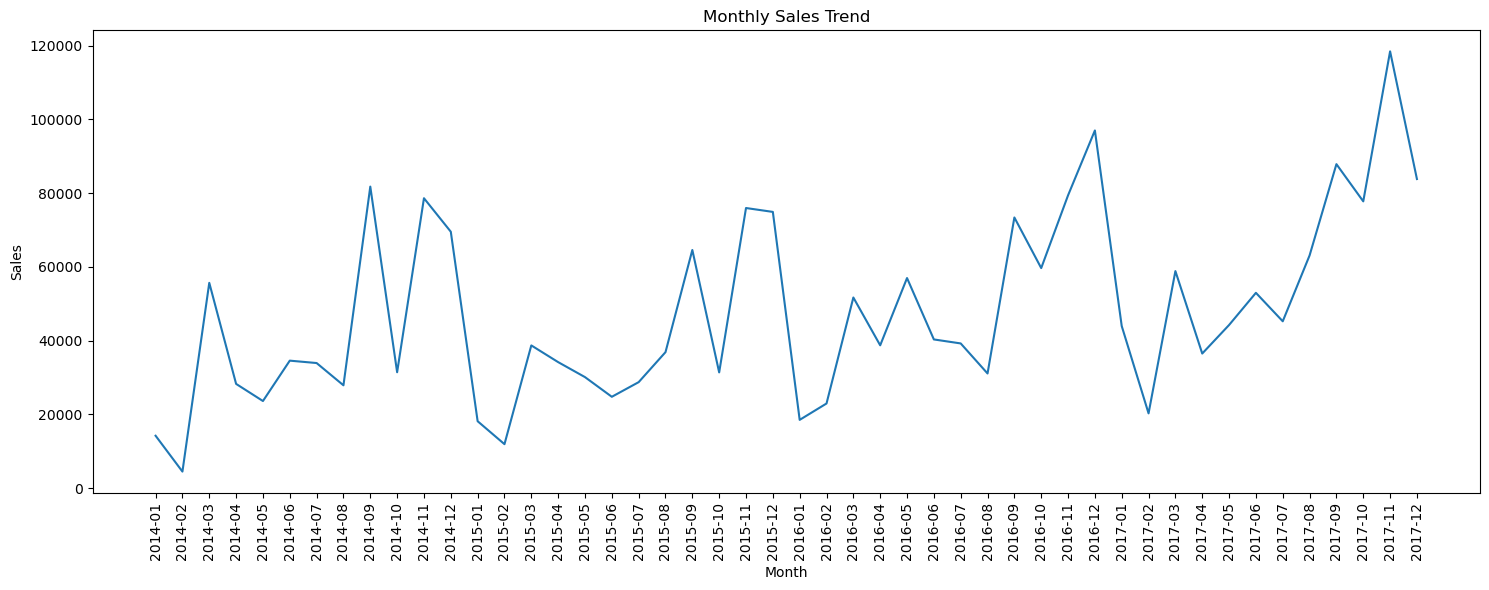

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Monthly Sales Trend Graph
plt.figure(figsize=(15,6))
plt.plot(monthly_sales['Month'].astype(str), monthly_sales['Sales'])
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

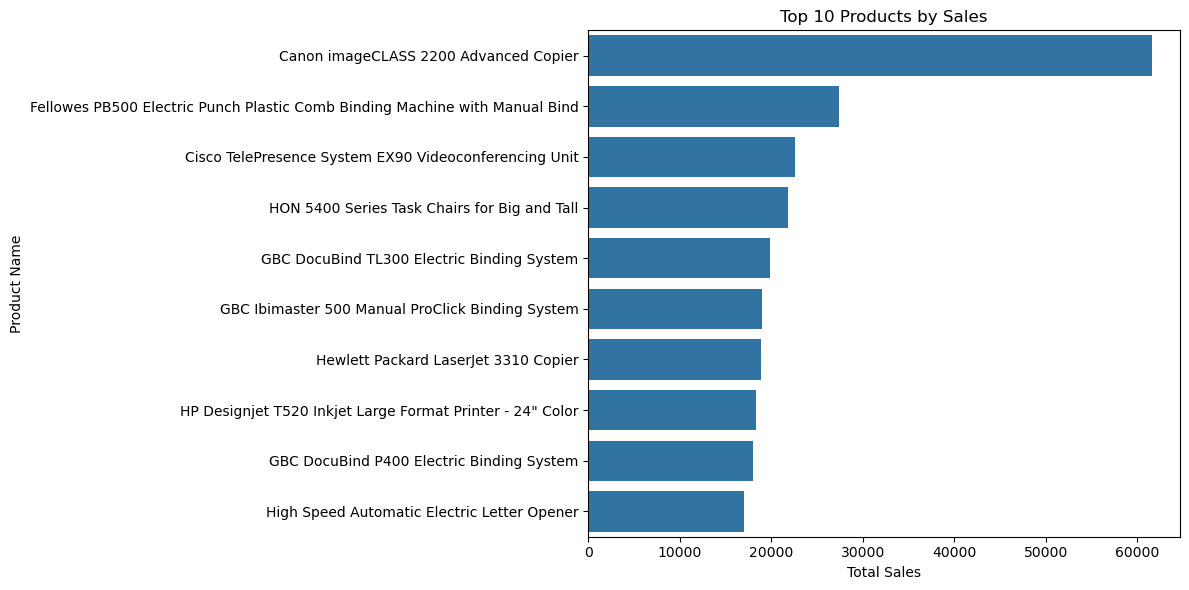

In [6]:
# Top 10 Products by Sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='Sales', y='Product Name', data=top_products)
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

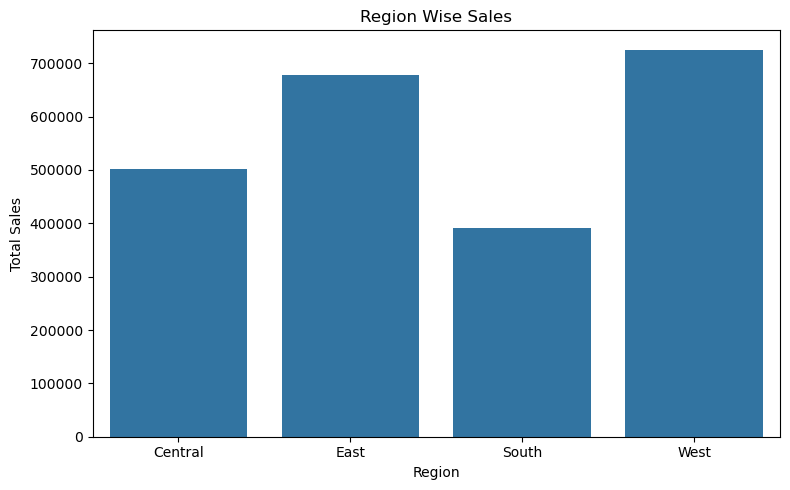

In [7]:
# Region wise Sales
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=region_sales)
plt.title('Region Wise Sales')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data for ML
monthly_sales['Month_Num'] = range(len(monthly_sales))

X = monthly_sales[['Month_Num']]
y = monthly_sales['Sales']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 12 months
future_months = pd.DataFrame({'Month_Num': range(len(monthly_sales), len(monthly_sales)+12)})
predictions = model.predict(future_months)

print("Next 12 Months Sales Forecast:")
for i, pred in enumerate(predictions):
    print(f"Month {i+1}: ${pred:,.2f}")

Next 12 Months Sales Forecast:
Month 1: $69,957.54
Month 2: $70,859.54
Month 3: $71,761.55
Month 4: $72,663.56
Month 5: $73,565.57
Month 6: $74,467.57
Month 7: $75,369.58
Month 8: $76,271.59
Month 9: $77,173.60
Month 10: $78,075.60
Month 11: $78,977.61
Month 12: $79,879.62


In [9]:
import pymysql
from sqlalchemy import create_engine

# create database and load data
# create database
engine = create_engine('mysql+pymysql://root:@localhost/superstore')

conn = pymysql.connect(host='localhost', user='root', password='')
cursor = conn.cursor()
cursor.execute('CREATE DATABASE IF NOT EXISTS superstore')
conn.close()

# load data into MySQL
df.to_sql('sales_data', con=engine, if_exists='replace', index=False)
print("Data loaded into MySQL successfully! ✅")

Data loaded into MySQL successfully! ✅


In [10]:
# Data verify kara
query = "SELECT * FROM sales_data LIMIT 5"
df_sql = pd.read_sql(query, con=engine)
print(df_sql)

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ... Region  \
0      Claire Gute   Consumer  United States        Henderson  ...  South   
1      Claire Gute   Consumer  United States        Henderson  ...  South   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   West   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  South   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  South   

        Product ID         Category Sub-Category  \
0  FUR-BO-

In [11]:
query2 = "SELECT `Product Name`, SUM(Sales) as Total_Sales FROM sales_data GROUP BY `Product Name` ORDER BY Total_Sales DESC LIMIT 10"
top_products_sql = pd.read_sql(query2, con=engine)
print(top_products_sql)

                                        Product Name  Total_Sales
0              Canon imageCLASS 2200 Advanced Copier    61599.824
1  Fellowes PB500 Electric Punch Plastic Comb Bin...    27453.384
2  Cisco TelePresence System EX90 Videoconferenci...    22638.480
3       HON 5400 Series Task Chairs for Big and Tall    21870.576
4         GBC DocuBind TL300 Electric Binding System    19823.479
5   GBC Ibimaster 500 Manual ProClick Binding System    19024.500
6               Hewlett Packard LaserJet 3310 Copier    18839.686
7  HP Designjet T520 Inkjet Large Format Printer ...    18374.895
8          GBC DocuBind P400 Electric Binding System    17965.068
9        High Speed Automatic Electric Letter Opener    17030.312


In [12]:
query3 = "SELECT Region, SUM(Sales) as Total_Sales, SUM(Profit) as Total_Profit FROM sales_data GROUP BY Region ORDER BY Total_Sales DESC"
region_sql = pd.read_sql(query3, con=engine)
print(region_sql)

    Region  Total_Sales  Total_Profit
0     West  725457.8245   108418.4489
1     East  678781.2400    91522.7800
2  Central  501239.8908    39706.3625
3    South  391721.9050    46749.4303


In [13]:
query4 = "SELECT Category, `Sub-Category`, SUM(Sales) as Total_Sales FROM sales_data GROUP BY Category, `Sub-Category` ORDER BY Total_Sales DESC"
category_sql = pd.read_sql(query4, con=engine)
print(category_sql)

           Category Sub-Category  Total_Sales
0        Technology       Phones  330007.0540
1         Furniture       Chairs  328449.1030
2   Office Supplies      Storage  223843.6080
3         Furniture       Tables  206965.5320
4   Office Supplies      Binders  203412.7330
5        Technology     Machines  189238.6310
6        Technology  Accessories  167380.3180
7        Technology      Copiers  149528.0300
8         Furniture    Bookcases  114879.9963
9   Office Supplies   Appliances  107532.1610
10        Furniture  Furnishings   91705.1640
11  Office Supplies        Paper   78479.2060
12  Office Supplies     Supplies   46673.5380
13  Office Supplies          Art   27118.7920
14  Office Supplies    Envelopes   16476.4020
15  Office Supplies       Labels   12486.3120
16  Office Supplies    Fasteners    3024.2800


In [14]:
# export CSV for Power Bi
monthly_sales.to_csv(r'C:\Users\Admin\Desktop\Sales Forecasting project\monthly_sales.csv', index=False)
top_products.to_csv(r'C:\Users\Admin\Desktop\Sales Forecasting project\top_products.csv', index=False)
region_sales.to_csv(r'C:\Users\Admin\Desktop\Sales Forecasting project\region_sales.csv', index=False)

future_df = pd.DataFrame({
    'Month': [f'Future Month {i+1}' for i in range(12)],
    'Predicted_Sales': predictions
})
future_df.to_csv(r'C:\Users\Admin\Desktop\Sales Forecasting project\forecast.csv', index=False)

print("Sagle CSV files export zale! ✅")
print("Ata Power BI madhe he files load kara!")

Sagle CSV files export zale! ✅
Ata Power BI madhe he files load kara!


In [15]:
future_df = pd.DataFrame({
    'Month': [f'Future Month {i+1}' for i in range(12)],
    'Predicted_Sales': predictions
})
future_df.to_csv(r'C:\Users\Admin\Desktop\Sales Forecasting project\forecast.csv', index=False)
print(future_df)
print("Done! ✅")

              Month  Predicted_Sales
0    Future Month 1     69957.535798
1    Future Month 2     70859.543330
2    Future Month 3     71761.550862
3    Future Month 4     72663.558395
4    Future Month 5     73565.565927
5    Future Month 6     74467.573459
6    Future Month 7     75369.580992
7    Future Month 8     76271.588524
8    Future Month 9     77173.596056
9   Future Month 10     78075.603589
10  Future Month 11     78977.611121
11  Future Month 12     79879.618653
Done! ✅


In [16]:
print(predictions)

[69957.53579787 70859.54333018 71761.55086249 72663.55839481
 73565.56592712 74467.57345943 75369.58099174 76271.58852405
 77173.59605636 78075.60358867 78977.61112098 79879.61865329]


In [17]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Train/Test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Retrain model on training data
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"R-Squared: {r2:.4f}")
print("Model Evaluation Complete! ✅")

RMSE: 23,416.38
R-Squared: 0.0342
Model Evaluation Complete! ✅
